In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

Load the final cleaned dataset produced after preprocessing and missing value imputation

In [2]:
file_path = '../data/processed/final_dataset.csv'

df = pd.read_csv(file_path)

df.head(5)

,country,year,ev_sales_share,ev_stock,ev_stock_share,charging_points
0,Australia,2011,0.0061,49.0,0.00039,480.0
1,Australia,2012,0.0290,300.0,0.00240,480.0
2,Australia,2013,0.0330,590.0,0.00460,480.0
3,Australia,2014,0.1500,1880.0,0.01400,480.0
4,Australia,2015,0.1900,3600.0,0.02700,480.0


In [3]:
# Sort data by country and year
df = df.sort_values(['country', 'year'])

# Create lag features
df['ev_stock_lag1'] = (
    df.groupby('country')['ev_stock'].shift(1)
)

df['ev_stock_share_lag1'] = (
    df.groupby('country')['ev_stock_share'].shift(1)
)

df['charging_points_lag1'] = (
    df.groupby('country')['charging_points'].shift(1)
)

# Check missing values created by lagging
df.isnull().sum()

country                  0
year                     0
ev_sales_share           0
ev_stock                 0
ev_stock_share           0
charging_points          0
ev_stock_lag1           39
ev_stock_share_lag1     39
charging_points_lag1    39
dtype: int64

In [4]:
# Remove rows with missing lag features
df = df.dropna(
    subset=[
        'ev_stock_lag1',
        'ev_stock_share_lag1',
        'charging_points_lag1'
    ]
)

# Verify dataset
print(df.shape)
print(df.isnull().sum())

(499, 9)
country                 0
year                    0
ev_sales_share          0
ev_stock                0
ev_stock_share          0
charging_points         0
ev_stock_lag1           0
ev_stock_share_lag1     0
charging_points_lag1    0
dtype: int64


In [5]:
features = [
    'ev_stock',
    'ev_stock_share',
    'charging_points',
    'ev_stock_lag1',
    'ev_stock_share_lag1',
    'charging_points_lag1'
]

target = 'ev_sales_share'

X = df[features]
y = df[target]

In [6]:
train = df[df['year'] <= 2022]
test = df[df['year'] > 2022]

X_train = train[features]
X_test = test[features]

y_train = train[target]
y_test = test[target]

print(X_train.shape)
print(X_test.shape)

(421, 6)
(78, 6)


In [7]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

R²   : 0.5796
MAE  : 6.5644
RMSE : 13.3607


In [8]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

coef_df.sort_values(
    'Coefficient',
    ascending=False
)

,Feature,Coefficient
1,ev_stock_share,2.973254
4,ev_stock_share_lag1,2.227582
0,ev_stock,0.000008
2,charging_points,-0.000009
5,charging_points_lag1,-0.000010
3,ev_stock_lag1,-0.000011


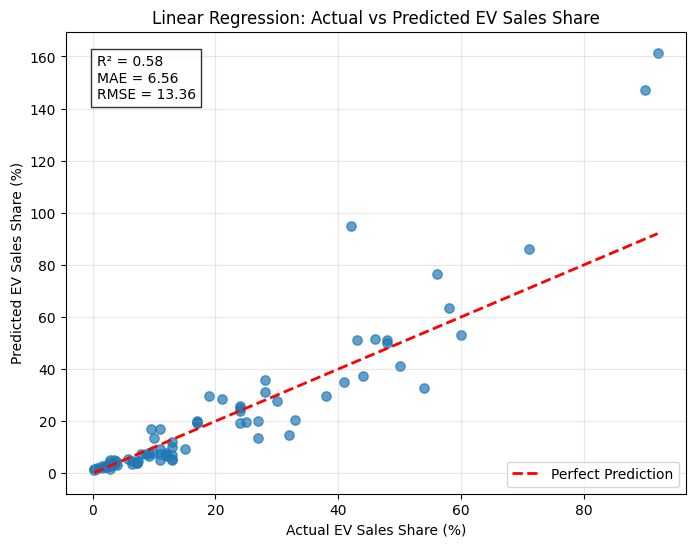

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7,          # Slight transparency
    s=45                # Marker size
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel("Actual EV Sales Share (%)")
plt.ylabel("Predicted EV Sales Share (%)")
plt.title("Linear Regression: Actual vs Predicted EV Sales Share")

plt.legend()

plt.text(
    0.05,
    0.95,
    f"R² = {r2:.2f}\nMAE = {mae:.2f}\nRMSE = {rmse:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.8)
)

plt.grid(alpha=0.3)

plt.show()